
Install

In [1]:
pip install timm seaborn

Note: you may need to restart the kernel to use updated packages.


Imports

In [2]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import timm

Reproducibility

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Data Augmentation

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Load Dataset

In [6]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import torch

# Set seed for reproducibility
torch.manual_seed(42)

dataset_path = "/home/ex5/Downloads/21MIS1007/Cashew_Dataset"  # path to single dataset folder

# Load full dataset WITHOUT transform first
full_dataset = datasets.ImageFolder(dataset_path)

total_size = len(full_dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", full_dataset.classes)

Train: 4609
Val: 987
Test: 989
Classes: ['Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner', 'Cashew red rust']


## Dataset Description

| Property | Value |
|----------|--------|
| Dataset Name | Cashew Leaf Disease Dataset |
| Total Images | 6585|
| Number of Classes | 5 |
| Classes | Anthracnose, Gumosis, Red Dust, Leaf Miner, Healthy |
| Image Resolution | 224 × 224 |
| Train Split | 70% |
| Validation Split | 15% |
| Test Split | 15% |
| Data Augmentation | Random Horizontal Flip, Rotation, Normalization |
| Preprocessing | Resize → Tensor → Normalize |

DataLoaders

In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Load EfficientNet-B4

In [8]:
num_classes = len(full_dataset.classes)

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

Loss, Optimizer, Scheduler

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5
)

## Training Configuration

| Parameter     | Value  |
|---------------|--------|
| Model         | EfficientNet (Pretrained) |
| Optimizer     | Adam |
| Learning Rate | 0.0001 |
| Batch Size    | 32 |
| Epochs        | 200 |
| Loss Function | CrossEntropyLoss |
| Scheduler     | ReduceLROnPlateau |
| Early Stopping Patience | 15 |
| Input Size    | 224 × 224 |
| Device        | GPU / CPU |


Training with Early Stopping

In [10]:
EPOCHS = 200
best_val_loss = float('inf')
patience = 15
counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):

    # ---------------------
    # TRAINING PHASE
    # ---------------------
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---------------------
    # VALIDATION PHASE
    # ---------------------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # ---------------------
    # STORE METRICS
    # ---------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ---------------------
    # SCHEDULER STEP
    # ---------------------
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(val_loss)
    else:
        scheduler.step()

    # ---------------------
    # PRINT PROGRESS
    # ---------------------
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ---------------------
    # EARLY STOPPING
    # ---------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_efficientnet_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# ---------------------
# LOAD BEST MODEL
# ---------------------
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.eval()

print("\nTraining Complete. Best model loaded.")


Epoch [1/200]
Train Loss: 0.4723 | Train Acc: 0.8221
Val Loss: 0.2399 | Val Acc: 0.9291

Epoch [2/200]
Train Loss: 0.0697 | Train Acc: 0.9811
Val Loss: 0.2405 | Val Acc: 0.9281

Epoch [3/200]
Train Loss: 0.0302 | Train Acc: 0.9946
Val Loss: 0.2489 | Val Acc: 0.9311

Epoch [4/200]
Train Loss: 0.0170 | Train Acc: 0.9957
Val Loss: 0.2473 | Val Acc: 0.9362

Epoch [5/200]
Train Loss: 0.0270 | Train Acc: 0.9911
Val Loss: 0.2227 | Val Acc: 0.9362

Epoch [6/200]
Train Loss: 0.0138 | Train Acc: 0.9957
Val Loss: 0.2285 | Val Acc: 0.9453

Epoch [7/200]
Train Loss: 0.0113 | Train Acc: 0.9963
Val Loss: 0.2268 | Val Acc: 0.9443

Epoch [8/200]
Train Loss: 0.0178 | Train Acc: 0.9954
Val Loss: 0.2316 | Val Acc: 0.9362

Epoch [9/200]
Train Loss: 0.0216 | Train Acc: 0.9926
Val Loss: 0.2005 | Val Acc: 0.9483

Epoch [10/200]
Train Loss: 0.0256 | Train Acc: 0.9922
Val Loss: 0.2086 | Val Acc: 0.9504

Epoch [11/200]
Train Loss: 0.0121 | Train Acc: 0.9967
Val Loss: 0.1990 | Val Acc: 0.9473

Epoch [12/200]
Tra

Training Curves

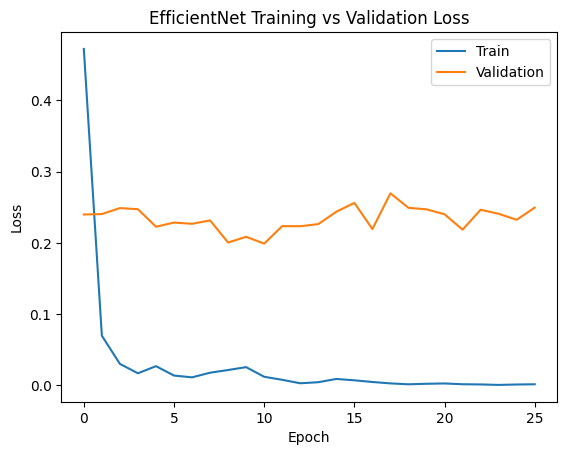

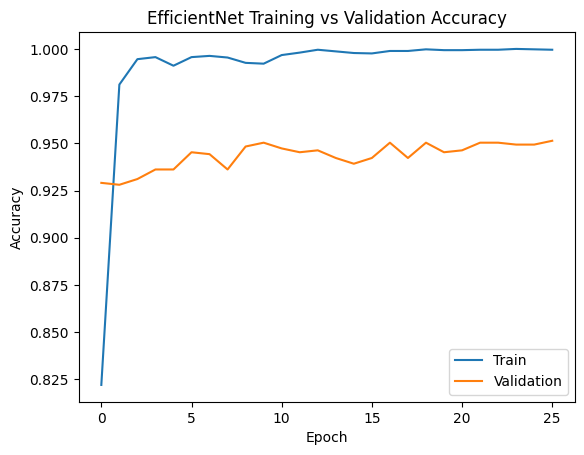

In [11]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

Test Evaluation + Confusion Matrix

Test Accuracy: 0.9514661274014156

Classification Report:

                    precision    recall  f1-score   support

Cashew anthracnose       0.92      0.92      0.92       242
    Cashew gumosis       0.97      0.98      0.98        61
    Cashew healthy       0.98      0.94      0.96       218
 Cashew leaf miner       0.94      0.95      0.94       206
   Cashew red rust       0.97      0.99      0.98       262

          accuracy                           0.95       989
         macro avg       0.95      0.96      0.95       989
      weighted avg       0.95      0.95      0.95       989



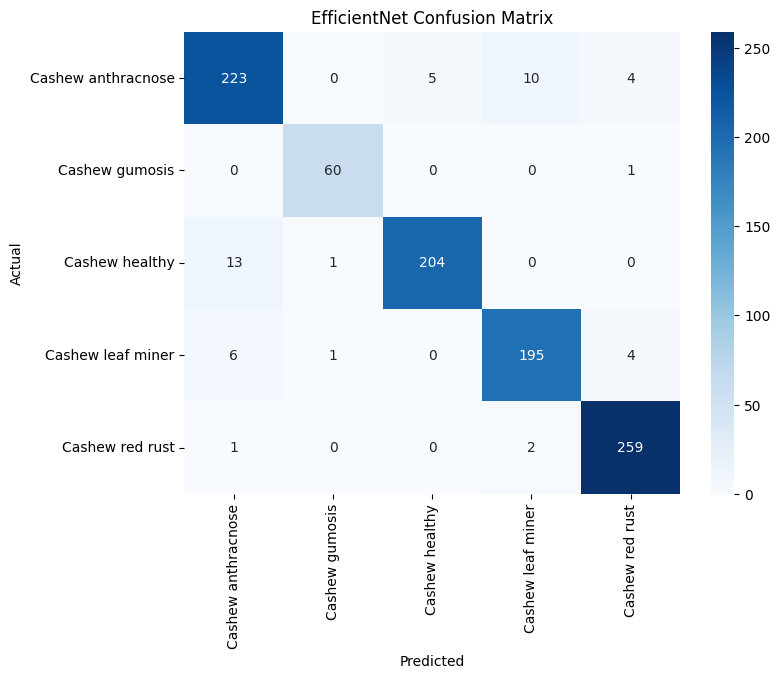

In [12]:
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Confusion Matrix")
plt.show()

Grad-CAM

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

model.eval()

gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# EfficientNet last convolution layer
target_layer = model.conv_head
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


def generate_efficientnet_gradcam(image_tensor):
    gradients.clear()
    activations.clear()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    output = model(image_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    loss = output[0, pred_class]
    model.zero_grad()
    loss.backward()

    grad = gradients[0].detach().cpu().numpy()
    act = activations[0].detach().cpu().numpy()

    weights = np.mean(grad, axis=(2,3))

    cam = np.zeros(act.shape[2:], dtype=np.float32)

    for i, w in enumerate(weights[0]):
        cam += w * act[0, i, :, :]

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (224, 224))

    return cam, pred_class

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


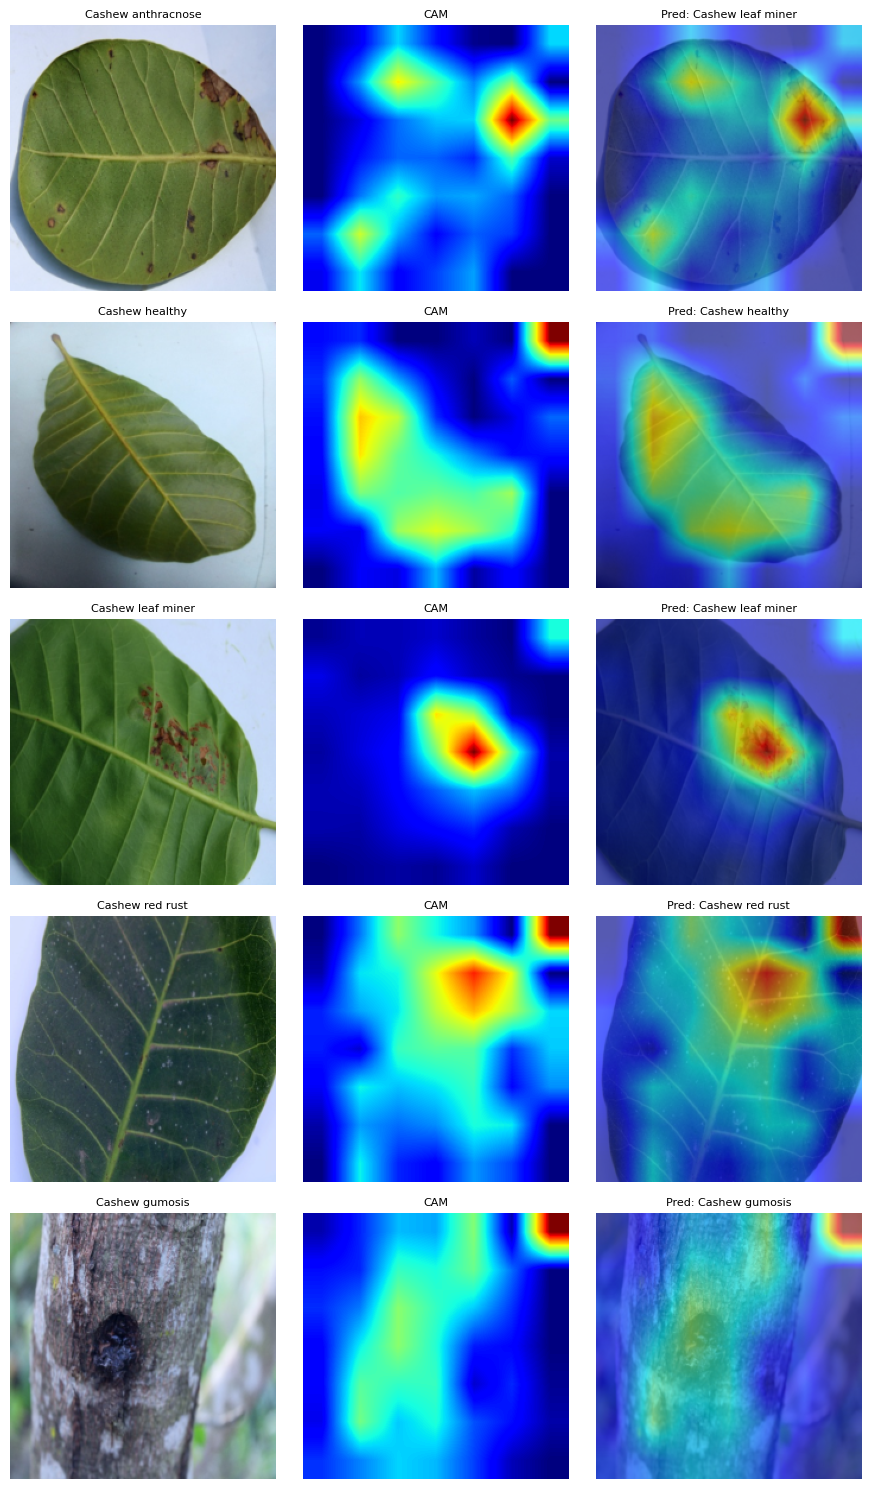

In [16]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

model.eval()

class_names = full_dataset.classes
num_classes = len(class_names)

# -----------------------------
# Random one image per class
# -----------------------------
samples_per_class = {}

indices = list(range(len(test_dataset)))
random.shuffle(indices)

for idx in indices:
    img, label = test_dataset[idx]
    if label not in samples_per_class:
        samples_per_class[label] = img
    if len(samples_per_class) == num_classes:
        break

# -----------------------------
# Smaller Visualization
# -----------------------------
plt.figure(figsize=(9, 3 * num_classes))  # Smaller figure

for i, (label, img) in enumerate(samples_per_class.items()):

    cam, pred_class = generate_efficientnet_gradcam(img)

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap / 255.0

    overlay = 0.6 * heatmap + 0.4 * img_np

    # Original
    plt.subplot(num_classes, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(class_names[label], fontsize=8)
    plt.axis("off")

    # Grad-CAM
    plt.subplot(num_classes, 3, i*3 + 2)
    plt.imshow(cam, cmap="jet")
    plt.title("CAM", fontsize=8)
    plt.axis("off")

    # Overlay
    plt.subplot(num_classes, 3, i*3 + 3)
    plt.imshow(overlay)
    plt.title(f"Pred: {class_names[pred_class]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()